# NYT Connections Puzzle Solver
## DATA 620 Final Project

Authors: Kevin Havis and Aaliyah John-Harry

## Introduction

The New York Times hosts several puzzle games on its website, but perhaps the most popular is Connections.

Connections is a word game where the player is given sixteen words and must group them into four categories of four words each based on hidden relationships or implicit patterns.

These relationships may be semantic, structural (prefixes/suffixes), or cultural references. The puzzle is intentionally designed to mislead players with plausible but incorrect groupings. In practice, players look for logical groups of four words, progressively eliminating words as they get the groupings correct.

Our goal is to develop a model that can automatically group the sixteen words into their correct categories using a combination of natural language processing (NLP) and network analysis techniques.

### Research Question
Can a combination of semantic embeddings and network-based clustering accurately identify the hidden groupings in NYT Connections puzzles, outperforming baseline methods such as random grouping and simple similarity measures?

### Hypothesis
We expect that combining word embeddings with network-based clustering will outperform both random grouping and simple cosine similarity, approaching human-level performance on historical puzzles.

### Potential Challenges/Concerns

- The primary challenge is the diversity of relationships between words.
    - Simple methods such as cosine similarity may capture semantic meaning but fail to detect structural or contextual patterns.
    - Additionally, the puzzle often intentionally misdirects the player by providing words that can be intuitively grouped but do not fit the predetermined category.
- Categories may rely on cultural knowledge not captured by NLP techniques.
    - Additionally, clustering evaluation is complex due to multiple plausible groupings. 

### Approach

We have several tools we can use to take on this problem.

#### Data

We will use historical NYT Connections puzzles and their solutions from a public GitHub dataset maintained by *Eyefyre* on [GitHub](https://github.com/Eyefyre/NYT-Connections-Answers).


#### Techniques

We must use a combination of techniques to address all potential "angles" of word classification.

- Word Embeddings: Vectorizing the words can give us some initial groupings of similar words by common language 
- Text Processing: Stemming and lemmatization will be used to identify structural relationships.
- Network analysis: Modeling the words as nodes and their connections as edges is a natural approach to this type of "neighbor" clustering

#### Evaluation

Model evaluation for clustering can be challenging; to measure our model's performance, we will compare against the following benchmarks.

- Random Association: Random grouping of words, measured by accuracy
- Simple Word Vector Embeddings: Groups based on semantic similarity.
- LLM Performance: Human-equivalent or better performance
- Human Benchmark: Comparison against known puzzle solutions.

Performance will be measured based on how accurately the model reproduces the correct groupings.

### Roles and Responsibilities

- Aaliyah John-Harry:
    - Text preprocessing
    - Feature engineering
    - Model development
- Kevin Havis:
    - Network construction
    - Graph analysis
    - Clustering methods
- Both:
    - Evaluation
    - Interpretation
    - Presentation

In [1]:
import os, sys

print(os.getcwd())
print(sys.path[:3])

/Users/aaliyahmjh/data_620/project4
['/Users/aaliyahmjh/data_620/project4', '/opt/anaconda3/lib/python312.zip', '/opt/anaconda3/lib/python3.12']


In [2]:
import importlib
import data
import embeddings

#importlib.reload(embeddings)
#importlib.reload(data)

In [3]:
# Note - import will take a while as we load all the GloVe embeddings
from data import DataLoader
from embeddings import Embedder

In [4]:
loader = DataLoader()
df = loader.df

In [5]:
puzzle_index = 0

raw_puzzle = loader.get_puzzle(puzzle_index)
words = loader.words[puzzle_index]

print(words)

['HAIL', 'RAIN', 'SLEET', 'SNOW', 'BUCKS', 'HEAT', 'JAZZ', 'NETS', 'OPTION', 'RETURN', 'SHIFT', 'TAB', 'KAYAK', 'LEVEL', 'MOM', 'RACECAR']


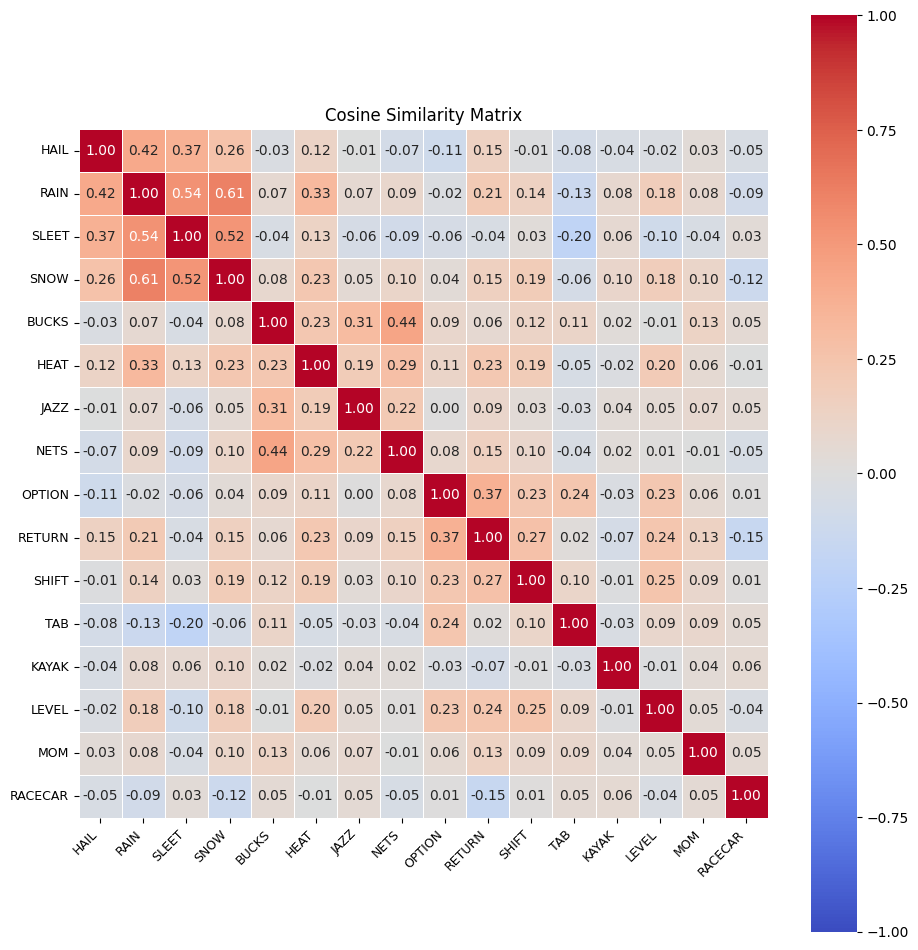

In [12]:
embedder = Embedder(words)

embedder.get_glove_embeddings()

similarity_matrix = embedder.get_cosine_similarity()

fig = embedder.plot_similarity_matrix()

In [16]:
from embeddings import rank_word_combinations

ranked_groups = rank_word_combinations(
    words,
    similarity_matrix
)

ranked_groups.head(20)

,combo_words,combo_indices,mean_cosine_similarity
0,"(HAIL, RAIN, SLEET, SNOW)","(0, 1, 2, 3)",0.452395
1,"(RAIN, SLEET, SNOW, HEAT)","(1, 2, 3, 5)",0.390996
2,"(RAIN, SLEET, SNOW, SHIFT)","(1, 2, 3, 10)",0.337398
3,"(RAIN, SLEET, SNOW, RETURN)","(1, 2, 3, 9)",0.329706
4,"(HAIL, RAIN, SNOW, HEAT)","(0, 1, 3, 5)",0.327892
5,"(RAIN, SLEET, SNOW, LEVEL)","(1, 2, 3, 13)",0.319314
6,"(HAIL, RAIN, SLEET, HEAT)","(0, 1, 2, 5)",0.317802
7,"(RAIN, SLEET, SNOW, KAYAK)","(1, 2, 3, 12)",0.317405
8,"(RAIN, SLEET, SNOW, MOM)","(1, 2, 3, 14)",0.300440
9,"(HAIL, RAIN, SNOW, RETURN)","(0, 1, 3, 9)",0.299162


In [19]:
def get_true_groups(raw_puzzle):

    true_groups = []

    for answer in raw_puzzle["answers"]:

        true_groups.append(
            frozenset(answer["members"])
        )

    return true_groups

In [20]:
true_groups = get_true_groups(raw_puzzle)

ranked_groups["is_true_group"] = ranked_groups[
    "combo_words"
].apply(lambda x: frozenset(x) in true_groups)

ranked_groups[
    ranked_groups["is_true_group"] == True
]

,combo_words,combo_indices,mean_cosine_similarity,rank,is_true_group
0,"(HAIL, RAIN, SLEET, SNOW)","(0, 1, 2, 3)",0.452395,1,True
16,"(BUCKS, HEAT, JAZZ, NETS)","(4, 5, 6, 7)",0.280209,17,True
80,"(OPTION, RETURN, SHIFT, TAB)","(8, 9, 10, 11)",0.205211,81,True
1517,"(KAYAK, LEVEL, MOM, RACECAR)","(12, 13, 14, 15)",0.024869,1518,True


In [21]:
ranked_groups["rank"] = ranked_groups.index + 1

In [22]:
ranked_groups[
    ranked_groups["is_true_group"] == True
]

,combo_words,combo_indices,mean_cosine_similarity,rank,is_true_group
0,"(HAIL, RAIN, SLEET, SNOW)","(0, 1, 2, 3)",0.452395,1,True
16,"(BUCKS, HEAT, JAZZ, NETS)","(4, 5, 6, 7)",0.280209,17,True
80,"(OPTION, RETURN, SHIFT, TAB)","(8, 9, 10, 11)",0.205211,81,True
1517,"(KAYAK, LEVEL, MOM, RACECAR)","(12, 13, 14, 15)",0.024869,1518,True


In [23]:
results = []

for puzzle_index in range(50):

    raw_puzzle = loader.get_puzzle(puzzle_index)
    words = loader.words[puzzle_index]

    embedder = Embedder(words)

    embedder.get_glove_embeddings()

    similarity_matrix = embedder.get_cosine_similarity()

    ranked_groups = rank_word_combinations(
        words,
        similarity_matrix
    )

    true_groups = get_true_groups(raw_puzzle)

    ranked_groups["is_true_group"] = ranked_groups[
        "combo_words"
    ].apply(lambda x: frozenset(x) in true_groups)

    ranked_groups["rank"] = ranked_groups.index + 1

    true_rankings = ranked_groups[
        ranked_groups["is_true_group"] == True
    ]["rank"].tolist()

    results.extend(true_rankings)

In [30]:
import numpy as np

average_true_group_rank = np.mean(results)
median_true_group_rank = np.median(results)

best_ranked_true_group = min(results)
worst_ranked_true_group = max(results)

print(f"Average true-group rank: {average_true_group_rank:.2f}")
print(f"Median true-group rank: {median_true_group_rank:.2f}")
print(f"Best-ranked true group: {best_ranked_true_group}")
print(f"Worst-ranked true group: {worst_ranked_true_group}")

Average true-group rank: 397.11
Median true-group rank: 180.00
Best-ranked true group: 1
Worst-ranked true group: 1809


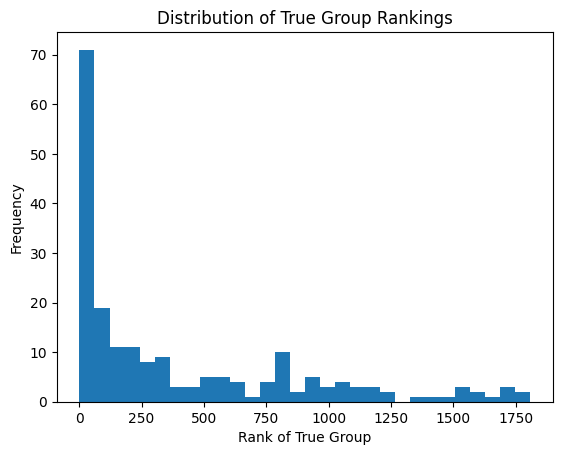

In [29]:
import matplotlib.pyplot as plt

plt.hist(results, bins=30)
plt.xlabel("Rank of True Group")
plt.ylabel("Frequency")
plt.title("Distribution of True Group Rankings")
plt.show()

The distribution of true-group rankings is strongly right-skewed. Many correct categories ranked very highly using cosine similarity, indicating that semantic embeddings effectively capture meaning-based relationships between words.

However, a subset of categories ranked extremely poorly. These low-performing categories were often based on structural or contextual relationships rather than semantic meaning, such as palindromes or keyboard keys.

This demonstrates that embedding-based similarity can serve as a strong baseline for solving NYT Connections puzzles, but semantic similarity alone is insufficient for handling the full range of puzzle patterns used by the game.